In [ ]:
import torchaudio
import matplotlib.pyplot as plt
import torch

from IPython import display

In [2]:
plt.rcParams["figure.figsize"] = (20, 6)

## Melspec creation

In [3]:
filepath = "data/LJSpeech-1.1/wavs/LJ001-0001.wav"

In [4]:
wav, sr = torchaudio.load(filepath)

In [96]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=22050,
    n_fft=1024,
    n_mels=80,
    win_length=1024,
    hop_length=256,
    f_min=0,
    f_max=8000,
    power=1.0,
    normalized=False,
    norm="slaney",
    mel_scale="slaney",
)

In [97]:
mel = torch.log(torch.clip(mel_transform(wav), min=1e-5))

In [98]:
mel.min(), mel.max()

(tensor(-11.5129), tensor(1.4659))

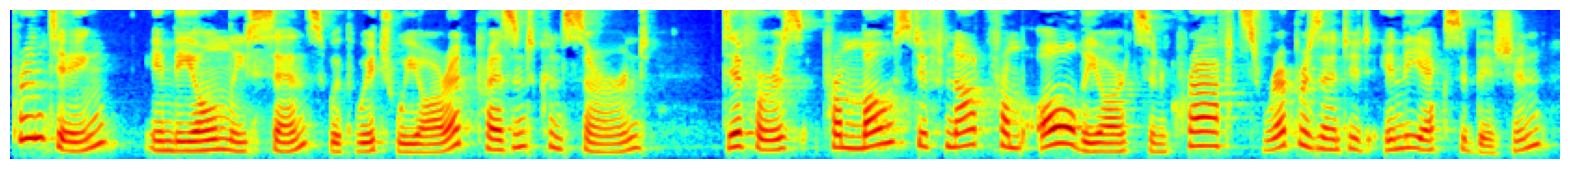

In [99]:
plt.imshow((mel[0].numpy()), origin="lower", cmap="jet")
plt.axis("off")
plt.show()

In [100]:
display.Audio(wav, rate=sr)

## Vocoding

In [101]:
import json
from hifigan.models import Generator as HiFiGAN

device = "cpu"

In [102]:
config_path = "checkpoints/hifigan/config.json"
ckpt_path = "checkpoints/hifigan/generator_V1"

In [103]:
class AttrDict(dict):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.__dict__ = self


with open(config_path, "r") as f:
    d = json.load(f)
    config = AttrDict(d)

In [104]:
hifigan = HiFiGAN(config)
ckpt = torch.load(ckpt_path, map_location=device)
hifigan.load_state_dict(ckpt["generator"])
hifigan.eval()
hifigan.remove_weight_norm()

Removing weight norm...


In [105]:
with torch.inference_mode():
    out = hifigan(mel)

wav_rec = out[0].cpu()

In [106]:
display.Audio(wav_rec.numpy(), rate=sr)

In [68]:
display.Audio(wav, rate=sr)

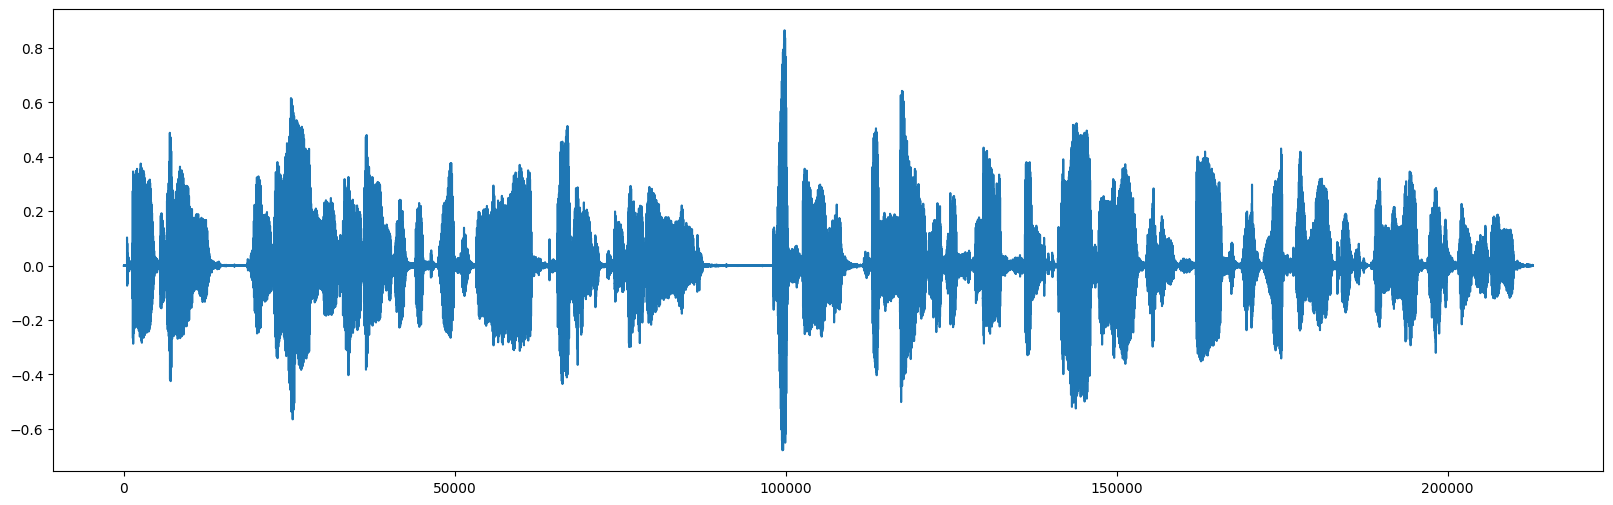

In [107]:
plt.plot(list(range(len(wav[0]))), wav[0])

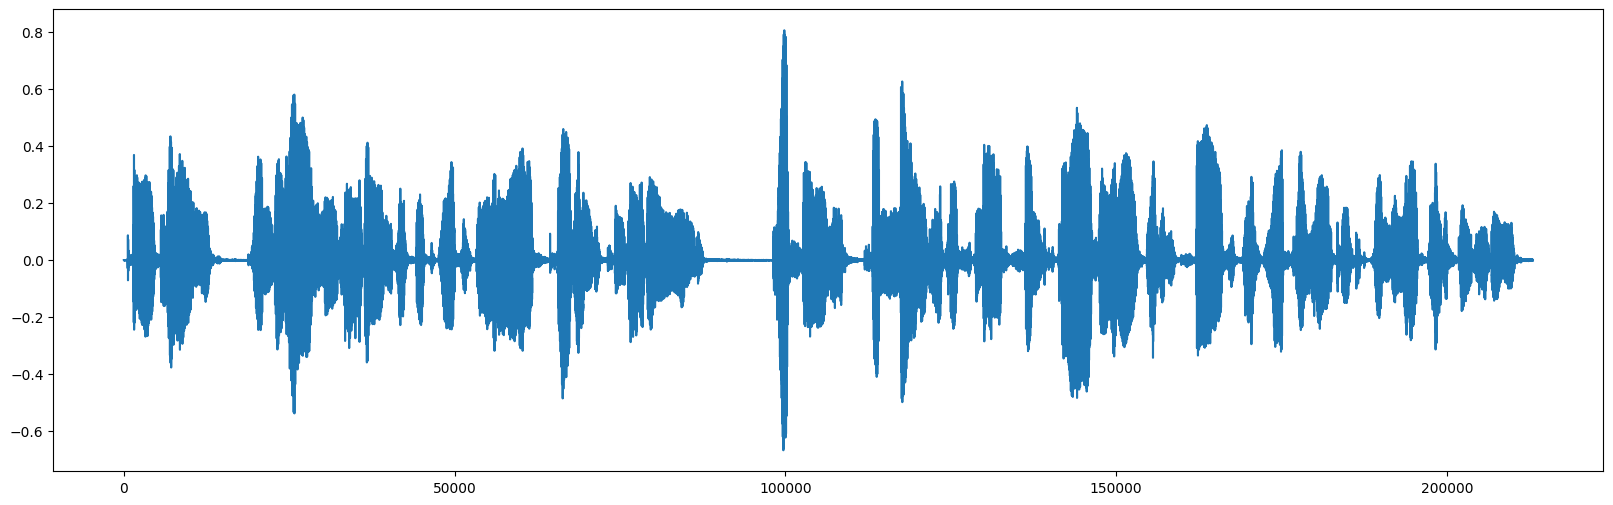

In [108]:
plt.plot(list(range(len(wav_rec[0]))), wav_rec[0])